In [ ]:
#
# Linear Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
#
# New Dataset: https://www.kaggle.com/datasets/yashpaloswal/ann-car-sales-price-prediction?select=car_purchasing.csv
#

import pandas as pd
df = pd.read_csv('car_purchasing.csv', encoding="latin-1") # erro no utf-8
df

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248
...,...,...,...,...,...,...,...,...,...
495,Walter,ligula@Cumsociis.ca,Nepal,0,41.462515,71942.40291,6995.902524,541670.1016,48901.44342
496,Vanna,Cum.sociis.natoque@Sedmolestie.edu,Zimbabwe,1,37.642000,56039.49793,12301.456790,360419.0988,31491.41457
497,Pearl,penatibus.et@massanonante.com,Philippines,1,53.943497,68888.77805,10611.606860,764531.3203,64147.28888
498,Nell,Quisque.varius@arcuVivamussit.net,Botswana,1,59.160509,49811.99062,14013.034510,337826.6382,45442.15353


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [ ]:
df.describe()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


<Axes: xlabel='annual Salary', ylabel='car purchase amount'>

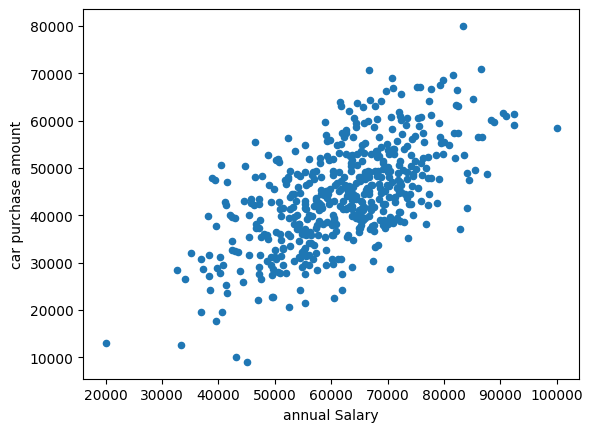

In [ ]:
df.plot(x = 'annual Salary', y = 'car purchase amount', kind = 'scatter') # relaciona salario e carro

In [ ]:
df.select_dtypes(include=['float64', 'int64']).corr()['car purchase amount'].sort_values(ascending=False)
# seleciona apenas numeros
# faz correlacao de todas as colunas numéricas e a coluna "car purchase amount"
# Ordena as correlações da coluna "car purchase amount" em ordem decrescente


,car purchase amount
car purchase amount,1.000000
age,0.632865
annual Salary,0.617862
net worth,0.488580
credit card debt,0.028882
gender,-0.066408


In [ ]:
# x = df.drop('car purchase amount', axis = 1) # Se for usar todas as características (features)

# Usando a característica que possui maior correlação com preço
# Equação final: y = a*X + b --> y = net_sqm*X + b

x = df[['annual Salary']]
y = df['car purchase amount']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [2]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train) # x não normaliza?
# car_purchase_amount=a⋅annual_salary+b

NameError: name 'x_train' is not defined

In [ ]:
lr.coef_ # coeficiente angular. f(x) = 0.57 X + B

array([0.57209414])

In [ ]:
lr.intercept_ #  # intercepto. f(x) = 0.57 X + 8237

np.float64(8237.879594432787)

In [1]:
# retorna R^2, o quanto consegue explicar prever (no caso, uns 30%)
lr.score(x_test, y_test)

NameError: name 'lr' is not defined

In [ ]:
# Mean Squared Error
y_pred = lr.predict(x_test) # Usa lr para prever o valor da compra do carro (y_pred) com base no teste (x_test).

from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_pred)

8372.53708877562

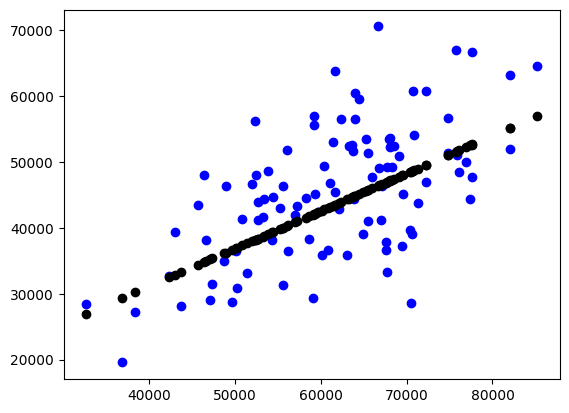

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_test['annual Salary'], y_test, color ='b')  # plota os pontos reais (dados de teste) em azul
plt.scatter(x_test['annual Salary'], y_pred, color ='k')     # plota a reta da regressão (valores previstos) em preto

plt.show()